# 📊 Finviz Intraday Patterns — v3
Análisis multi-día de transiciones de categoría y señales.
- Fuente: DB de producción (`~/Library/Application Support/finviz-dashboard/finviz_snapshots.db`)
- Todas las agrupaciones de `shift()` son dentro de `(ticker, date)` — sin contaminación inter-día
- `future_change` calculado dentro del mismo día (sin look-ahead cross-day)
- Sección de consistencia multi-día al final para validar que los patrones no son ruido de un día

## 1. Imports y configuración

In [18]:
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

DB_PROD  = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
DB_BURST = Path('..') / 'burst_intraday_cache.db'

## 2. Carga y limpieza de datos

In [19]:
conn = sqlite3.connect(DB_PROD)
df = pd.read_sql("SELECT timestamp, category, ticker, price, change_pct, volume FROM snapshots", conn)
conn.close()

# --- Limpieza ---
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_convert('America/New_York')
df['date'] = df['timestamp'].dt.date

# change_pct: quitar % → float
df['change_pct'] = pd.to_numeric(
    df['change_pct'].astype(str).str.replace('%', '', regex=False).str.replace(',', '', regex=False),
    errors='coerce'
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

# volume: sufijos M/K/B (Finviz los guarda como strings legibles)
def parse_volume(v):
    v = str(v).strip().replace(',', '')
    if v.endswith('M'):
        return float(v[:-1]) * 1_000_000
    elif v.endswith('K'):
        return float(v[:-1]) * 1_000
    elif v.endswith('B'):
        return float(v[:-1]) * 1_000_000_000
    else:
        return pd.to_numeric(v, errors='coerce')

df['volume'] = df['volume'].apply(parse_volume)

df = df.dropna(subset=['change_pct', 'volume']).copy()

# Ordenar por ticker, date, timestamp — imprescindible para shift() correcto
df = df.sort_values(['ticker', 'date', 'timestamp']).reset_index(drop=True)

print(df.dtypes)
print(f"\nRows: {len(df):,}  |  Días: {df['date'].nunique()}  |  Tickers: {df['ticker'].nunique()}")
print(f"\nVolumen (sample): {df['volume'].describe().round(0)}")

timestamp     datetime64[ns, America/New_York]
category                                object
ticker                                  object
price                                  float64
change_pct                             float64
volume                                 float64
date                                    object
dtype: object

Rows: 49,855  |  Días: 25  |  Tickers: 1083

Volumen (sample): count    4.985500e+04
mean     6.321787e+07
std      1.650614e+08
min      0.000000e+00
25%      4.520200e+05
50%      3.740000e+06
75%      4.134000e+07
max      2.400000e+09
Name: volume, dtype: float64


## 3. Overview rápido

In [20]:
print("Shape:", df.shape)
print("\nCategorías:")
print(df['category'].value_counts())
print("\nSnaps por día (total filas):")
print(df.groupby('date').size().to_string())
print("\nSnaps por (ticker, día) — distribución:")
print(df.groupby(['ticker', 'date']).size().describe().round(1))
print("\nTickers únicos:", df['ticker'].nunique())

Shape: (49855, 7)

Categorías:
category
Top Gainers        7924
Top Losers         7904
New High           5248
Unusual Volume     5248
New Low            5248
Most Active        2624
Overbought         2624
Oversold           2624
Most Volatile      2623
Upgrades           1312
Insider Selling    1312
Downgrades         1312
Insider Buying     1312
Earnings After     1280
Earnings Before    1260
Name: count, dtype: int64

Snaps por día (total filas):
date
2026-03-24     988
2026-03-25     950
2026-03-26     950
2026-03-27     988
2026-03-30     988
2026-04-01     342
2026-04-02     988
2026-04-06     988
2026-04-07     988
2026-04-08     988
2026-04-09     950
2026-04-10    1976
2026-04-13    2888
2026-04-14    2698
2026-04-15    2926
2026-04-16    2926
2026-04-17    2926
2026-04-20    2925
2026-04-21    2926
2026-04-22    2926
2026-04-23    2926
2026-04-24    2926
2026-04-27    2926
2026-04-28    2926
2026-04-29    2926

Snaps por (ticker, día) — distribución:
count    2312.0
mean   

## 4. Transiciones de categorías

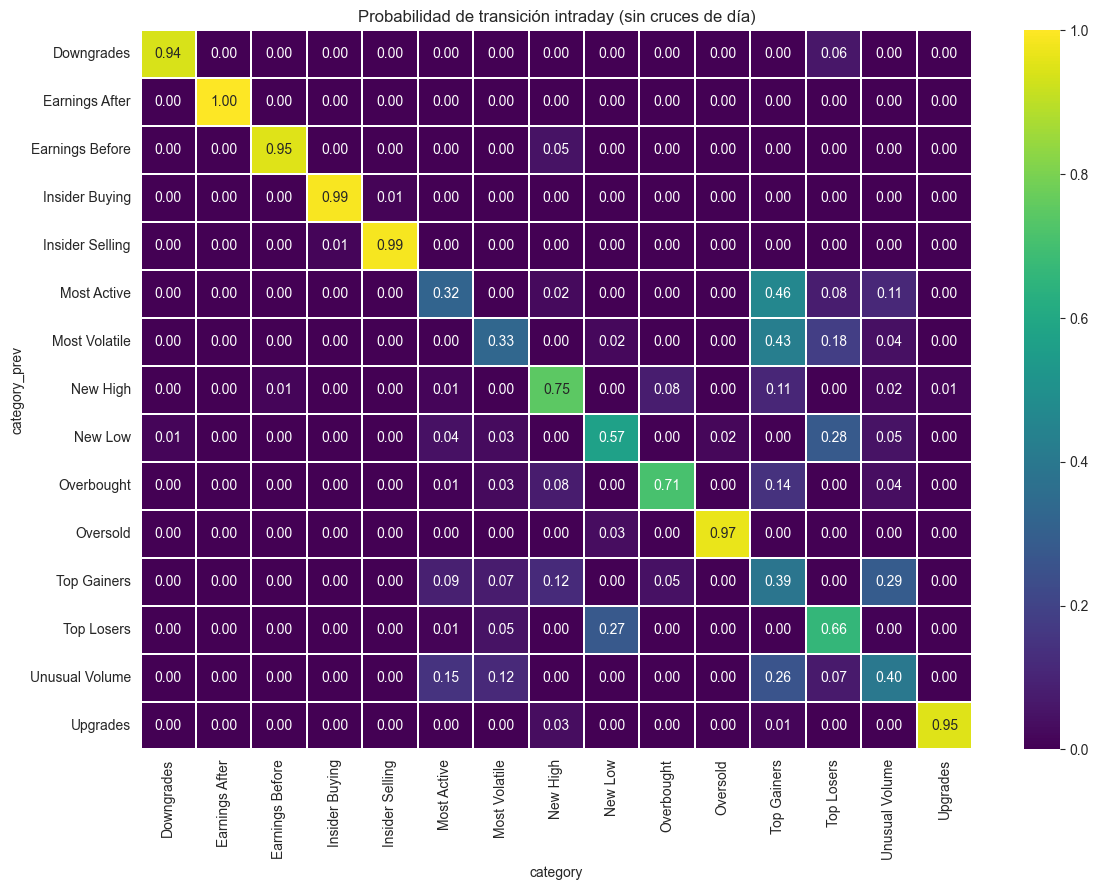


Transiciones totales: 47,543  (de 49,855 observaciones)


In [21]:
# FIX: shift dentro de (ticker, date) — nunca cruzar días
df['category_prev'] = df.groupby(['ticker', 'date'])['category'].shift(1)

# Solo transiciones intraday reales (no la primera obs del día, que es NaN)
trans = df.dropna(subset=['category_prev'])

transition_counts = pd.crosstab(trans['category_prev'], trans['category'])
transition_probs  = transition_counts.div(transition_counts.sum(axis=1), axis=0)

plt.figure(figsize=(12, 9))
sns.heatmap(transition_probs, cmap='viridis', annot=True, fmt='.2f', linewidths=0.3)
plt.title("Probabilidad de transición intraday (sin cruces de día)")
plt.tight_layout()
plt.show()

print(f"\nTransiciones totales: {len(trans):,}  (de {len(df):,} observaciones)")

## 5. Evolución intradía

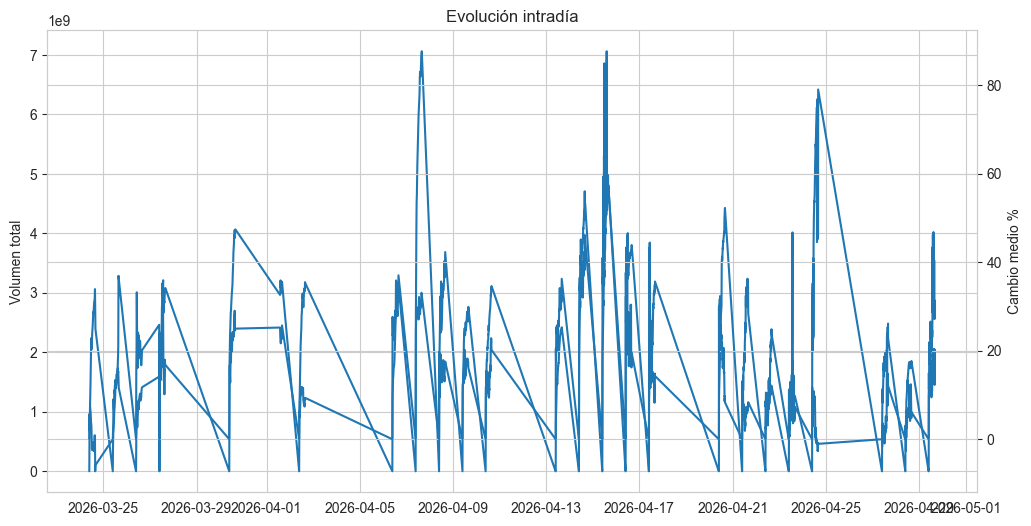

In [22]:

agg = df.groupby('timestamp').agg({
    'volume':'sum',
    'change_pct':'mean'
})

fig, ax1 = plt.subplots()

ax1.plot(agg.index, agg['volume'])
ax1.set_ylabel("Volumen total")

ax2 = ax1.twinx()
ax2.plot(agg.index, agg['change_pct'])
ax2.set_ylabel("Cambio medio %")

plt.title("Evolución intradía")
plt.show()


## 6. Dominancia de categorías

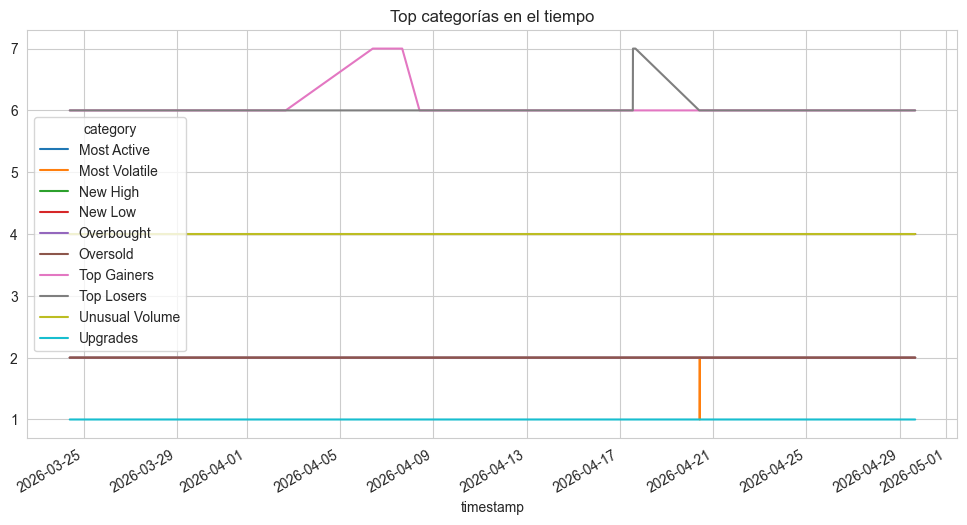

In [23]:

top_cat = df['category'].value_counts().head(10).index

pivot = df[df['category'].isin(top_cat)].groupby(['timestamp','category'])['ticker'].nunique().unstack()

pivot.plot()
plt.title("Top categorías en el tiempo")
plt.show()


## 7. Persistencia de estado

In [24]:
# FIX: state_change y state_group dentro de (ticker, date)
df['state_change'] = (df['category'] != df['category_prev']).astype(int)
# Primera obs de cada ticker/día: tratar como inicio de nuevo estado
df['state_change'] = df['state_change'].fillna(1).astype(int)
df['state_group'] = df.groupby(['ticker', 'date'])['state_change'].cumsum()

duration = df.groupby(['ticker', 'date', 'state_group']).agg(
    category=('category', 'first'),
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_snaps=('timestamp', 'count')
).reset_index()

duration['duration_min'] = (duration['end'] - duration['start']).dt.total_seconds() / 60

print("Duración media por categoría (minutos):")
print(duration.groupby('category')['duration_min'].mean().sort_values(ascending=False).round(1))
duration.head(10)

Duración media por categoría (minutos):
category
Earnings After     349.0
Oversold           124.9
Upgrades            95.7
Earnings Before     95.7
Downgrades          85.8
Insider Buying      63.0
Overbought          24.1
New High            20.9
Insider Selling     20.7
Top Losers          15.7
New Low             10.4
Top Gainers          6.2
Unusual Volume       4.8
Most Volatile        3.5
Most Active          2.9
Name: duration_min, dtype: float64


,ticker,date,state_group,category,start,end,n_snaps,duration_min
0,AA,2026-04-09,1,Upgrades,2026-04-09 09:44:59-04:00,2026-04-09 15:48:15-04:00,25,363.266667
1,AAOI,2026-04-09,1,New High,2026-04-09 10:00:09-04:00,2026-04-09 13:47:14-04:00,15,227.083333
2,AAOI,2026-04-10,1,Insider Selling,2026-04-10 13:34:04-04:00,2026-04-10 13:39:08-04:00,2,5.066667
3,AAON,2026-04-24,1,Insider Selling,2026-04-24 11:33:52-04:00,2026-04-24 12:04:10-04:00,7,30.300000
4,AAON,2026-04-27,1,Insider Selling,2026-04-27 13:35:25-04:00,2026-04-27 15:32:12-04:00,4,116.783333
5,AAON,2026-04-29,1,Insider Selling,2026-04-29 10:35:12-04:00,2026-04-29 10:35:12-04:00,1,0.000000
6,AAPL,2026-04-17,1,Upgrades,2026-04-17 09:32:30-04:00,2026-04-17 15:57:22-04:00,77,384.866667
7,ABBV,2026-04-29,1,Earnings Before,2026-04-29 09:34:25-04:00,2026-04-29 15:59:06-04:00,77,384.683333
8,ABEV,2026-04-16,1,Downgrades,2026-04-16 09:32:43-04:00,2026-04-16 15:56:51-04:00,77,384.133333
9,ABLV,2026-04-17,1,Unusual Volume,2026-04-17 09:47:41-04:00,2026-04-17 11:23:50-04:00,20,96.150000


## 8. Volumen vs cambio

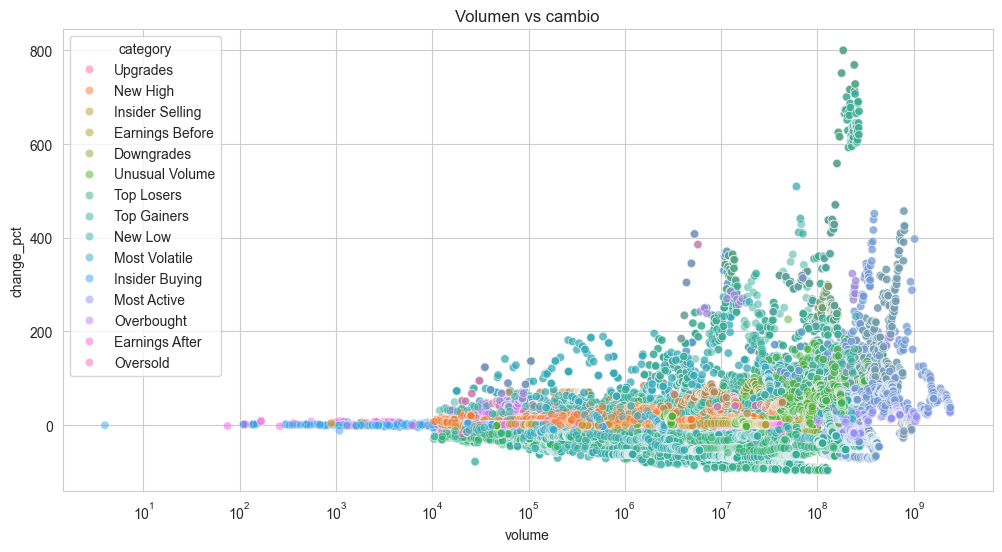

In [25]:

sns.scatterplot(data=df, x='volume', y='change_pct', hue='category', alpha=0.5)
plt.xscale('log')
plt.title("Volumen vs cambio")
plt.show()


## 9. Spikes de volumen

In [26]:

threshold = df['volume'].quantile(0.99)
spikes = df[df['volume'] > threshold]

print("Número de spikes:", len(spikes))

spikes.head()


Número de spikes: 499


,timestamp,category,ticker,price,change_pct,volume,date,category_prev,state_change,state_group
3101,2026-04-06 13:03:47-04:00,Top Gainers,AIXI,0.37,182.10,706620000.0,2026-04-06,Most Active,1,27
3102,2026-04-06 13:03:47-04:00,Most Active,AIXI,0.37,182.10,706620000.0,2026-04-06,Top Gainers,1,28
3103,2026-04-06 13:18:54-04:00,Top Gainers,AIXI,0.34,158.07,729000000.0,2026-04-06,Most Active,1,29
3104,2026-04-06 13:18:54-04:00,Most Active,AIXI,0.34,158.07,729000000.0,2026-04-06,Top Gainers,1,30
3105,2026-04-06 13:34:02-04:00,Top Gainers,AIXI,0.36,174.98,750360000.0,2026-04-06,Most Active,1,31


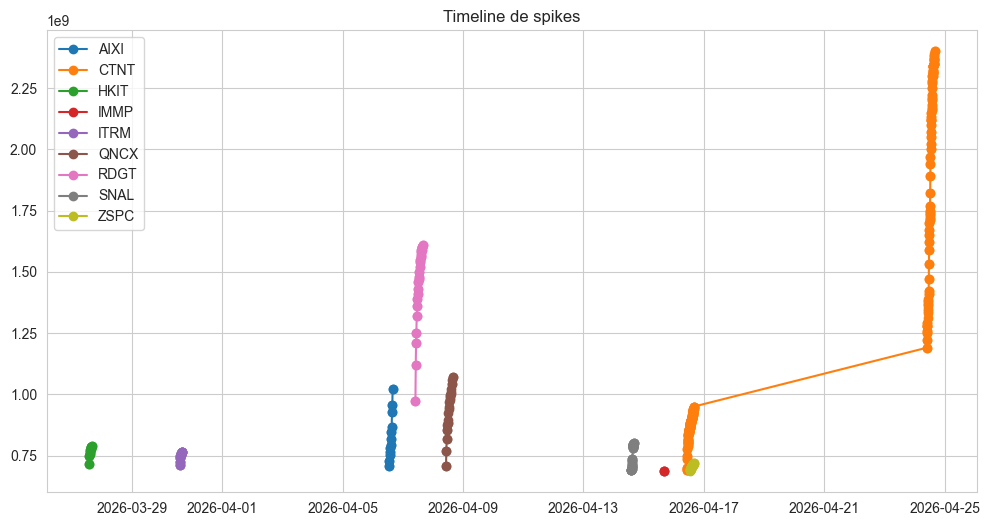

In [27]:

plt.figure()

for ticker in spikes['ticker'].unique():
    sub = spikes[spikes['ticker']==ticker]
    plt.plot(sub['timestamp'], sub['volume'], marker='o', label=ticker)

plt.legend()
plt.title("Timeline de spikes")
plt.show()


## 10. Secuencias de categorías

In [28]:
# FIX: secuencias dentro del mismo día (no mezclar días)
# Para cada (ticker, date), concatenar las primeras 5 categorías del día
sequences = (
    df.groupby(['ticker', 'date'])['category']
    .apply(lambda x: ' → '.join(x.head(5)))
    .reset_index(name='sequence')
)

print("Top 15 secuencias intraday más frecuentes:")
print(sequences['sequence'].value_counts().head(15).to_string())

Top 15 secuencias intraday más frecuentes:
sequence
Insider Selling                                                                            186
Top Losers → Top Losers → Top Losers → Top Losers → Top Losers                             128
Top Gainers → Top Gainers → Top Gainers → Top Gainers → Top Gainers                        115
New High → New High → New High → New High → New High                                       100
Insider Selling → Insider Selling                                                           98
Insider Selling → Insider Selling → Insider Selling → Insider Selling → Insider Selling     79
New Low → New Low → New Low → New Low → New Low                                             79
Top Losers                                                                                  70
Insider Buying → Insider Buying → Insider Buying → Insider Buying → Insider Buying          69
Oversold → Oversold → Oversold → Oversold → Oversold                                        6

## 11. Feature engineering

In [29]:
df['vol_rank']   = df.groupby(['date', 'timestamp'])['volume'].rank(pct=True)
df['abs_change'] = df['change_pct'].abs()
df['direction']  = np.sign(df['change_pct'])

df[['ticker', 'date', 'timestamp', 'category', 'change_pct', 'vol_rank', 'direction']].head()

,ticker,date,timestamp,category,change_pct,vol_rank,direction
0,AA,2026-04-09,2026-04-09 09:44:59-04:00,Upgrades,0.00,0.513158,0.0
1,AA,2026-04-09,2026-04-09 10:00:09-04:00,Upgrades,4.36,0.473684,1.0
2,AA,2026-04-09,2026-04-09 10:15:19-04:00,Upgrades,3.47,0.526316,1.0
3,AA,2026-04-09,2026-04-09 10:30:29-04:00,Upgrades,2.40,0.513158,1.0
4,AA,2026-04-09,2026-04-09 10:45:39-04:00,Upgrades,2.56,0.447368,1.0


## 12. Lag / comportamiento futuro

In [30]:
# FIX: future_change dentro de (ticker, date) — sin look-ahead cross-day
# shift(-5) dentro del mismo día: si no hay 5 obs más en el mismo día, queda NaN (correcto)
df['future_change'] = df.groupby(['ticker', 'date'])['change_pct'].shift(-5)

result = df.groupby('category')['future_change'].agg(['mean', 'median', 'count'])
result.columns = ['mean_fut_chg', 'median_fut_chg', 'n']
result = result.sort_values('mean_fut_chg', ascending=False)

print("Cambio futuro medio (+5 snaps, mismo día) por categoría:")
print(result[result['n'] >= 20].round(3).to_string())

Cambio futuro medio (+5 snaps, mismo día) por categoría:
                 mean_fut_chg  median_fut_chg     n
category                                           
Top Gainers            83.798          61.840  6805
Most Volatile          60.026          26.710  2243
Unusual Volume         55.653          36.650  4617
Most Active            45.565          28.730  2387
Overbought             31.934           3.270  2207
New High               27.909          18.150  4415
Upgrades                4.520           2.520  1188
Earnings Before         1.455           1.740  1133
Insider Selling         0.372           0.240   211
Insider Buying          0.329           0.270   837
Earnings After          0.298           0.395  1148
Oversold               -4.698          -3.150  2250
Downgrades             -5.275          -2.445  1180
New Low               -34.019         -28.550  4366
Top Losers            -37.471         -32.970  6528


## 13. Clustering de tickers

In [31]:
from sklearn.cluster import KMeans

features = df.groupby('ticker').agg(
    volume_mean=('volume', 'mean'),
    change_pct_mean=('change_pct', 'mean'),
    abs_change_mean=('abs_change', 'mean'),
    n_days=('date', 'nunique')
).dropna()

# Solo tickers con al menos 2 días de historia (evita clustering sobre un único snapshot)
features = features[features['n_days'] >= 2].copy()

kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
features['cluster'] = kmeans.fit_predict(features[['volume_mean', 'change_pct_mean', 'abs_change_mean']])

print(f"Tickers en clustering: {len(features)}  (con >= 2 días)")
print("\nCaracterísticas por cluster:")
print(features.groupby('cluster')[['volume_mean', 'change_pct_mean', 'abs_change_mean']].mean().round(2))
features.head()

Tickers en clustering: 517  (con >= 2 días)

Características por cluster:
          volume_mean  change_pct_mean  abs_change_mean
cluster                                                
0        4.641086e+08            74.15            88.61
1        7.047634e+06             2.15            20.64
2        1.197548e+08            57.93            71.49
3        2.879783e+08            61.13            71.62


,volume_mean,change_pct_mean,abs_change_mean,n_days,cluster
ticker,,,,,
AAOI,8.721176e+06,2.690588,3.983529,2,1
AAON,4.490625e+05,-1.336667,3.020000,3,1
ABNB,1.288310e+06,0.678571,1.187647,6,1
ABVE,1.910000e+06,-12.602000,12.602000,2,1
ACHV,4.103572e+06,-6.764375,27.470625,3,1


## 14. KPI final

## 15. Consistencia multi-día de transiciones

¿Las probabilidades de transición observadas son estables entre días o artefacto de un día concreto?
Calculamos la matriz de transición para cada día y comparamos la dispersión.

/var/folders/gq/9ld2fqzs1gg0_d83b_rn_vgc0000gn/T/ipykernel_11107/237623140.py:21: RuntimeWarning: invalid value encountered in divide
  cv_mat   = np.where(mean_mat > 0, std_mat / mean_mat, np.nan)  # coef. de variación


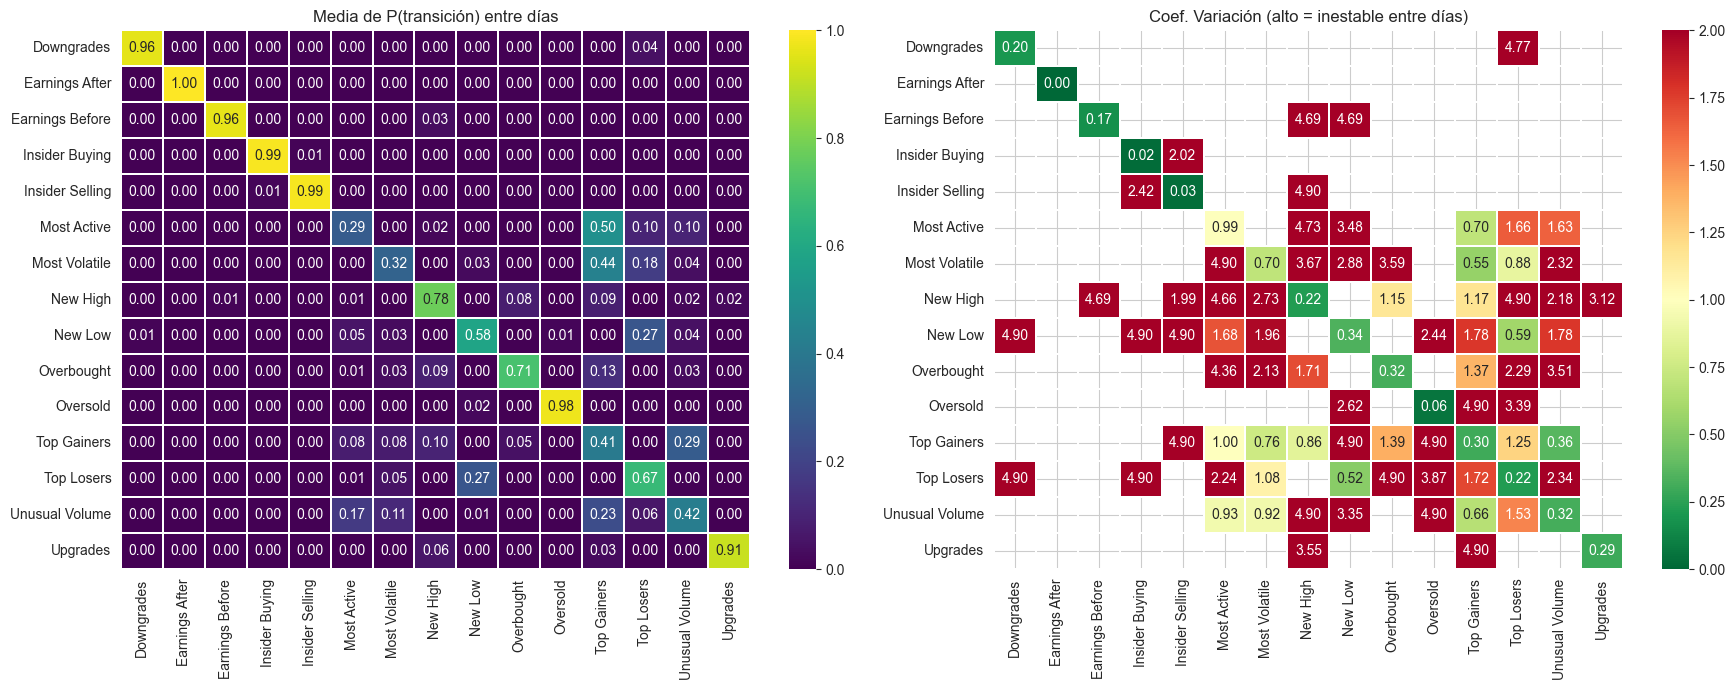


Transiciones más estables (p > 5%, cv bajo):


'           from              to  mean_p   cv\n Earnings After  Earnings After   1.000 0.00\n Insider Buying  Insider Buying   0.989 0.02\nInsider Selling Insider Selling   0.986 0.03\n       Oversold        Oversold   0.975 0.06\nEarnings Before Earnings Before   0.963 0.17\n     Downgrades      Downgrades   0.960 0.20\n       New High        New High   0.777 0.22\n     Top Losers      Top Losers   0.673 0.22\n       Upgrades        Upgrades   0.915 0.29\n    Top Gainers     Top Gainers   0.407 0.30\n     Overbought      Overbought   0.707 0.32\n Unusual Volume  Unusual Volume   0.420 0.32\n        New Low         New Low   0.585 0.34\n    Top Gainers  Unusual Volume   0.289 0.36\n     Top Losers         New Low   0.265 0.52'

In [32]:
trans = df.dropna(subset=['category_prev'])

# Matriz de transición por día
daily_probs = {}
for day, grp in trans.groupby('date'):
    counts = pd.crosstab(grp['category_prev'], grp['category'])
    probs  = counts.div(counts.sum(axis=1), axis=0)
    daily_probs[day] = probs

# Alinear todas las matrices al mismo índice/columnas
all_cats = sorted(trans['category'].unique())
daily_stack = {}
for day, mat in daily_probs.items():
    mat = mat.reindex(index=all_cats, columns=all_cats, fill_value=np.nan)
    daily_stack[day] = mat

stacked = np.stack([m.values for m in daily_stack.values()])  # (n_days, n_cats, n_cats)

mean_mat = np.nanmean(stacked, axis=0)
std_mat  = np.nanstd(stacked,  axis=0)
cv_mat   = np.where(mean_mat > 0, std_mat / mean_mat, np.nan)  # coef. de variación

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(pd.DataFrame(mean_mat, index=all_cats, columns=all_cats),
            ax=axes[0], cmap='viridis', annot=True, fmt='.2f', linewidths=0.3)
axes[0].set_title("Media de P(transición) entre días")

sns.heatmap(pd.DataFrame(cv_mat, index=all_cats, columns=all_cats),
            ax=axes[1], cmap='RdYlGn_r', annot=True, fmt='.2f', linewidths=0.3,
            vmin=0, vmax=2)
axes[1].set_title("Coef. Variación (alto = inestable entre días)")

plt.tight_layout()
plt.show()

# Pares de transición más estables (CV bajo, P media alta)
rows = []
for i, cat_from in enumerate(all_cats):
    for j, cat_to in enumerate(all_cats):
        p  = mean_mat[i, j]
        cv = cv_mat[i, j]
        if not np.isnan(p) and p > 0.05:
            rows.append({'from': cat_from, 'to': cat_to, 'mean_p': round(p, 3), 'cv': round(cv, 2) if not np.isnan(cv) else np.nan})

stable = pd.DataFrame(rows).sort_values(['cv', 'mean_p'], ascending=[True, False])
print("\nTransiciones más estables (p > 5%, cv bajo):")
stable.head(15).to_string(index=False)

## 16. Permutation test — ¿son las transiciones distintas del azar?

Shuffle las categorías dentro de cada día 500 veces y compara la diagonal observada vs la distribución nula.
Si la diagonal observada está fuera del percentil 95 de la distribución nula → hay señal real de persistencia.

Persistencia observada: 0.6174  (sobre 49,371 filas con >1 snap/día)


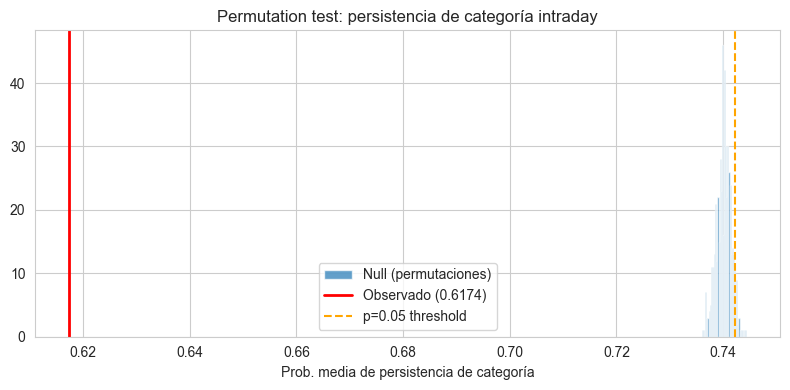

p-value: 1.0000  (no significativo)
Null: media=0.7401, 95th=0.7422


In [33]:
rng = np.random.default_rng(42)
N_PERM = 500

def diagonal_mean_prob(df_sub):
    """Prob media de que la categoría siguiente = misma categoría (persistencia intraday)."""
    df_sub = df_sub.copy()
    df_sub['cat_prev'] = df_sub.groupby(['ticker', 'date'])['category'].shift(1)
    valid = df_sub.dropna(subset=['cat_prev'])
    if len(valid) == 0:
        return np.nan
    return (valid['category'] == valid['cat_prev']).mean()

obs_stat = diagonal_mean_prob(df)
print(f"Persistencia observada: {obs_stat:.4f}  (sobre {df.groupby(['ticker','date']).filter(lambda x: len(x)>1).shape[0]:,} filas con >1 snap/día)")

# Null distribution: shuffle categorías dentro de cada (ticker, date)
null_stats = []
for _ in range(N_PERM):
    df_perm = df.copy()
    df_perm['category'] = (
        df_perm.groupby(['ticker', 'date'])['category']
        .transform(lambda x: rng.permutation(x.values))
    )
    null_stats.append(diagonal_mean_prob(df_perm))

null_stats = np.array(null_stats)
p_value = (null_stats >= obs_stat).mean()

plt.figure(figsize=(8, 4))
plt.hist(null_stats, bins=40, alpha=0.7, label='Null (permutaciones)')
plt.axvline(obs_stat, color='red', linewidth=2, label=f'Observado ({obs_stat:.4f})')
plt.axvline(np.percentile(null_stats, 95), color='orange', linestyle='--', label='p=0.05 threshold')
plt.xlabel("Prob. media de persistencia de categoría")
plt.title("Permutation test: persistencia de categoría intraday")
plt.legend()
plt.tight_layout()
plt.show()

print(f"p-value: {p_value:.4f}  {'*** SIGNIFICATIVO' if p_value < 0.05 else '(no significativo)'}")
print(f"Null: media={null_stats.mean():.4f}, 95th={np.percentile(null_stats, 95):.4f}")

In [34]:
summary = df.groupby('category').agg(
    volume_mean=('volume', 'mean'),
    change_pct_mean=('change_pct', 'mean'),
    future_change_mean=('future_change', 'mean'),
    n=('ticker', 'count')
).sort_values('future_change_mean', ascending=False)

print("KPI final por categoría:")
summary

KPI final por categoría:


,volume_mean,change_pct_mean,future_change_mean,n
category,,,,
Top Gainers,1.235015e+08,78.578033,83.797991,7924
Most Volatile,2.544187e+07,54.187430,60.026188,2623
Unusual Volume,1.207783e+08,52.337702,55.652805,5248
Most Active,3.925135e+08,44.853960,45.565182,2624
Overbought,1.279593e+07,28.439367,31.933729,2624
New High,1.097062e+07,25.474186,27.908888,5248
Upgrades,6.428997e+06,4.243247,4.520362,1312
Earnings Before,6.995882e+06,1.399024,1.454801,1260
Insider Selling,1.978289e+06,0.617195,0.371943,1312
